In [ ]:
# Google Drive'ı Bağla
from google.colab import drive
drive.mount('/content/drive')

# Veri yolunu belirt
import pandas as pd

# Örneğin dosya yolu (kendi dizinine göre güncelle)
file_path = '/content/drive/MyDrive/trafikk/trafikveri.csv'

# CSV'yi oku
df = pd.read_csv(file_path)

# İlk 5 satıra göz at
df.head()


Mounted at /content/drive


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [ ]:
# Gerekli kütüphane
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Tarih sütununu datetime formatına çevir
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')

# Yeni zaman sütunları ekle
df['year'] = df['crash_date'].dt.year
df['month'] = df['crash_date'].dt.month
df['day'] = df['crash_date'].dt.day
df['hour'] = df['crash_date'].dt.hour

# Kategorik sütunları label encoding ile sayısal hale getir
categorical_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    if col != 'crash_date':  # tarih sütunu hariç
        df[col] = le.fit_transform(df[col].astype(str))


<ipython-input-2-c9e03ce90a1f>:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')


In [ ]:
print(df.isnull().sum())


crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
year                             0
month                            0
day                              0
hour                             0
dtype: int64


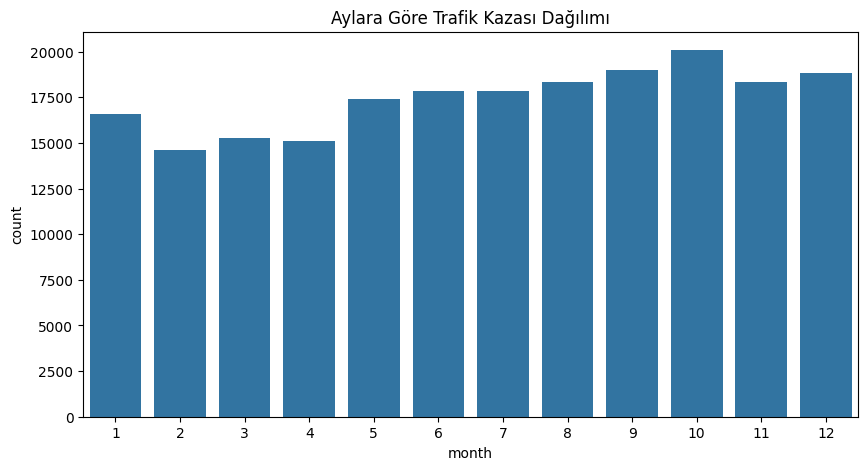

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x='month', data=df)
plt.title('Aylara Göre Trafik Kazası Dağılımı')
plt.show()


In [ ]:
# 'crash_date' gibi tarih türündeki sütunları çıkar
X = df.drop(['injuries_total', 'crash_date'], axis=1)
y = df['injuries_total']

# Eğitim ve test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model eğitimi
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Değerlendirme
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.001259614925230519
RMSE: 0.05376425661425848
R2 Score: 0.9955168318505511


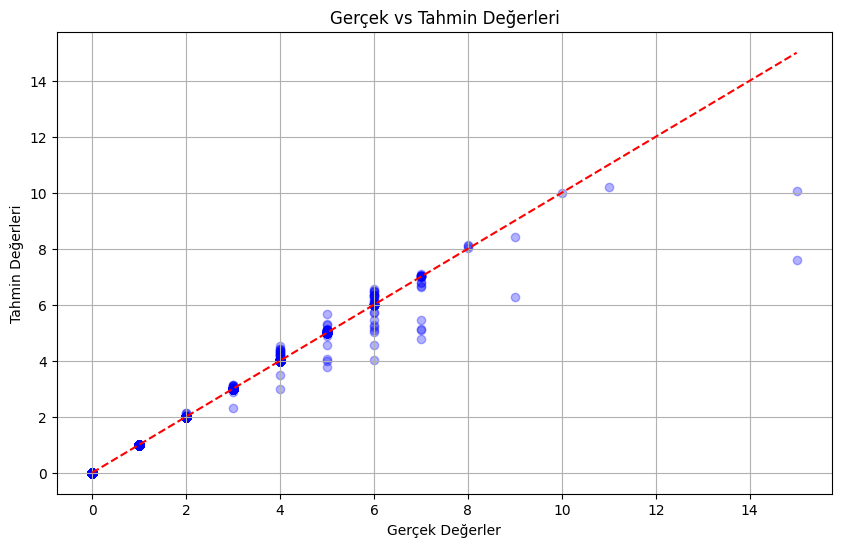

In [ ]:
import matplotlib.pyplot as plt

# Gerçek vs Tahmin grafiği
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # referans çizgisi
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Değerleri')
plt.title('Gerçek vs Tahmin Değerleri')
plt.grid(True)
plt.show()


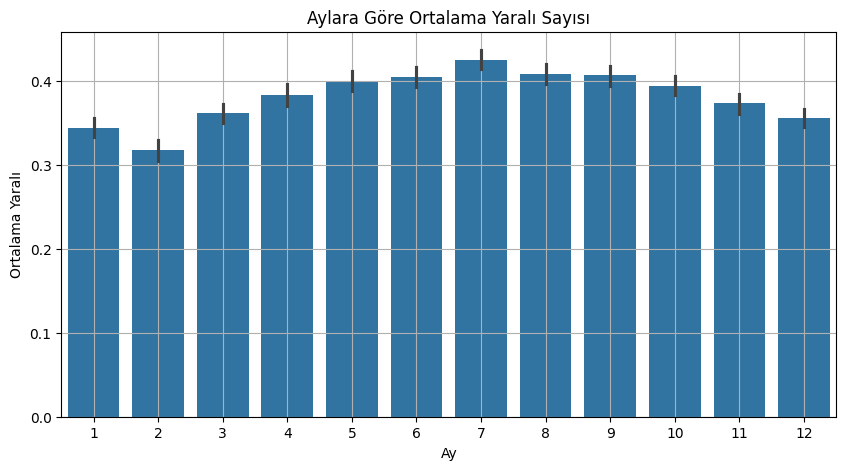

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.barplot(x='month', y='injuries_total', data=df)
plt.title("Aylara Göre Ortalama Yaralı Sayısı")
plt.xlabel("Ay")
plt.ylabel("Ortalama Yaralı")
plt.grid(True)
plt.show()


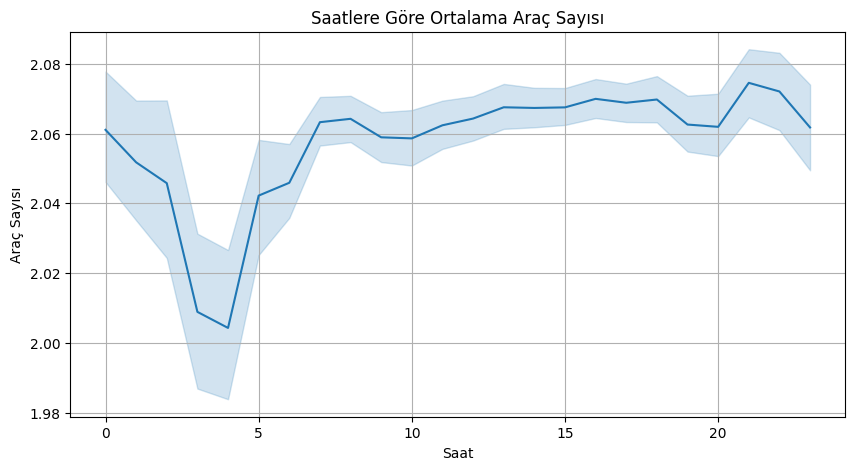

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='num_units', data=df)
plt.title("Saatlere Göre Ortalama Araç Sayısı")
plt.xlabel("Saat")
plt.ylabel("Araç Sayısı")
plt.grid(True)
plt.show()


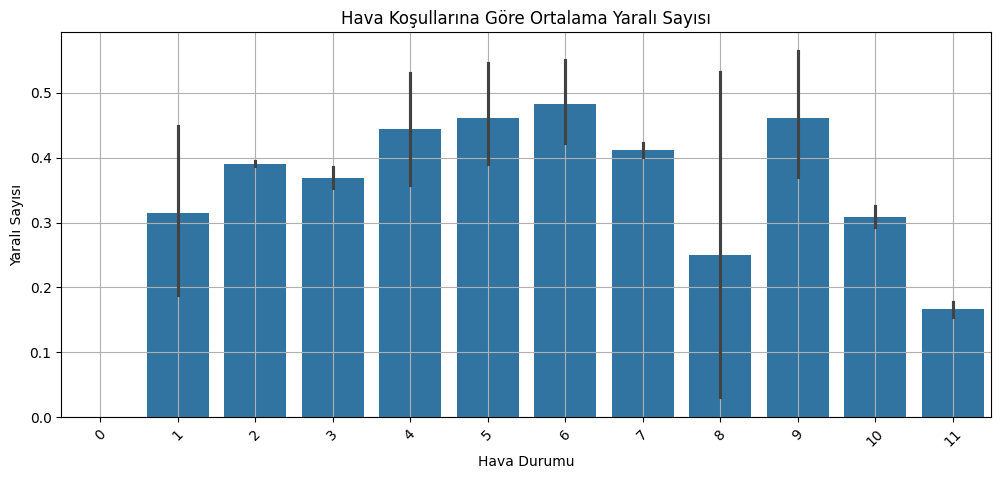

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(x='weather_condition', y='injuries_total', data=df)
plt.title("Hava Koşullarına Göre Ortalama Yaralı Sayısı")
plt.xlabel("Hava Durumu")
plt.ylabel("Yaralı Sayısı")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import joblib
import numpy as np


In [ ]:
# Slider: Saat
saat_slider = widgets.IntSlider(value=12, min=0, max=23, description='Saat:')

# Dropdown: Gün
gun_dropdown = widgets.Dropdown(
    options=[('Pazartesi', 1), ('Salı', 2), ('Çarşamba', 3),
             ('Perşembe', 4), ('Cuma', 5), ('Cumartesi', 6), ('Pazar', 7)],
    value=1,
    description='Gün:'
)

# Dropdown: Hava durumu (koda göre, LabelEncoder ile eşleşmeli)
hava_dropdown = widgets.Dropdown(
    options=[('Clear', 2), ('Rain', 6), ('Snow', 9)],
    value=2,
    description='Hava:'
)

# Dropdown: Yol tipi (örnek)
yol_dropdown = widgets.Dropdown(
    options=[('Not Divided', 8), ('Four Way', 6), ('T-Intersection', 15)],
    value=8,
    description='Yol:'
)


In [ ]:
import joblib

# Eğittiğin modeli kaydet
joblib.dump(model, 'trained_model.pkl')


['trained_model.pkl']

In [ ]:
model = joblib.load("trained_model.pkl")


In [ ]:
import joblib
model = joblib.load("trained_model.pkl")


def tahmin_buton_func(b):
    girdi = np.array([[saat_slider.value, gun_dropdown.value, hava_dropdown.value, yol_dropdown.value]])
    tahmin = model.predict(girdi)[0]
    display(Markdown(f"### Tahmini Yaralı Sayısı: **{tahmin:.2f}**"))


In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

In [ ]:
import os
os.remove("trained_model.pkl")


In [ ]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Sadece 4 özellik
features = ['hour', 'crash_day_of_week', 'weather_condition', 'trafficway_type']
X = df[features]
y = df['injuries_total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

# Yeni modeli KAYDET
joblib.dump(model, 'trained_model.pkl')


['trained_model.pkl']

In [ ]:
model = joblib.load("trained_model.pkl")


In [ ]:
def tahmin_buton_func(b):
    girdi = np.array([[saat_slider.value, gun_dropdown.value, hava_dropdown.value, yol_dropdown.value]])
    tahmin = model.predict(girdi)[0]
    display(Markdown(f"### Tahmini Yaralı Sayısı: **{tahmin:.2f}**"))


In [ ]:
# Buton
buton = widgets.Button(description='Tahmin Et')
buton.on_click(tahmin_buton_func)

# Arayüzü göster
display(saat_slider, gun_dropdown, hava_dropdown, yol_dropdown, buton)


IntSlider(value=16, description='Saat:', max=23)

Dropdown(description='Gün:', index=4, options=(('Pazartesi', 1), ('Salı', 2), ('Çarşamba', 3), ('Perşembe', 4)…

Dropdown(description='Hava:', index=2, options=(('Clear', 2), ('Rain', 6), ('Snow', 9)), value=9)

Dropdown(description='Yol:', index=2, options=(('Not Divided', 8), ('Four Way', 6), ('T-Intersection', 15)), v…

Button(description='Tahmin Et', style=ButtonStyle())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### 🚑 Tahmini Yaralı Sayısı: **0.57**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### 🚑 Tahmini Yaralı Sayısı: **0.36**